In [1]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/DS102

Mounted at /content/drive
/content/drive/MyDrive/DS102


Đọc JSON dạng lines OK: preprocessed-dataset/train_processed.json
Đọc JSON dạng lines OK: preprocessed-dataset/dev_processed.json
Đọc JSON dạng lines OK: preprocessed-dataset/test_processed.json
Train shape: (1710, 2)
Val shape: (244, 2)
Test shape: (490, 2)
Classes: ['negative', 'neutral', 'positive']
Train label distribution:
 sentiment
neutral     674
negative    529
positive    507
Name: count, dtype: int64
Đang huấn luyện và chọn tham số tốt nhất dựa trên VAL (F1-macro)...
Best VAL F1-macro: 0.6735081292490119
Best params:
nb__alpha: 0.3
nb__norm: False
tfidf__max_df: 0.2
tfidf__ngram_range: (1, 3)

DEV Accuracy: 0.6721311475409836
DEV F1-macro: 0.6735081292490119

Classification report (DEV):
              precision    recall  f1-score   support

    negative       0.68      0.74      0.71        76
     neutral       0.62      0.69      0.65        96
    positive       0.76      0.58      0.66        72

    accuracy                           0.67       244
   macro avg       0

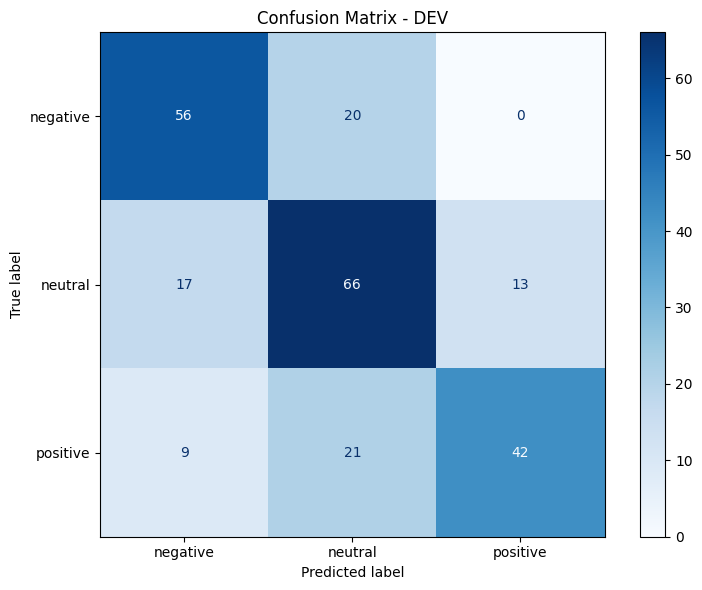


TEST Accuracy: 0.7142857142857143
TEST F1-macro: 0.7111903090639964

Classification report (TEST):
              precision    recall  f1-score   support

    negative       0.75      0.80      0.77       151
     neutral       0.70      0.73      0.71       194
    positive       0.70      0.60      0.65       145

    accuracy                           0.71       490
   macro avg       0.71      0.71      0.71       490
weighted avg       0.71      0.71      0.71       490



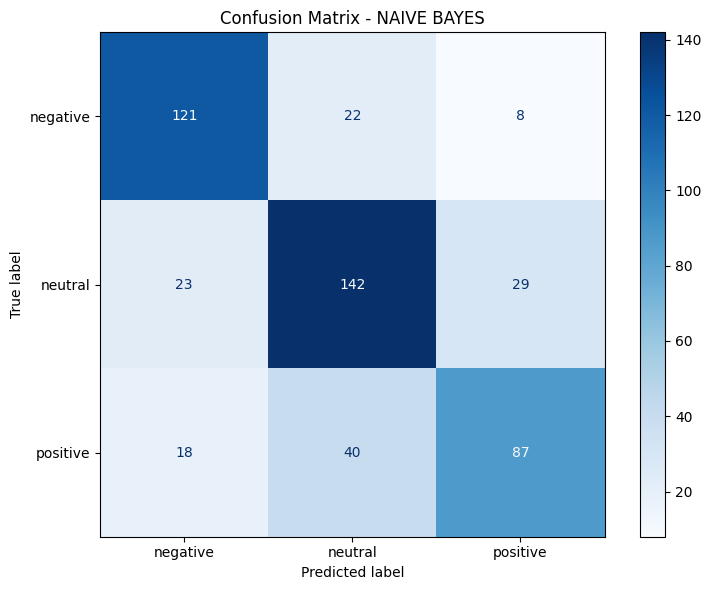

In [3]:
import pandas as pd
import re
import unicodedata
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import ComplementNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    ConfusionMatrixDisplay
)


# =========================
# 1) Load dữ liệu (train/val/test)
# =========================

TRAIN_PATH = "preprocessed-dataset/train_processed.json"
VAL_PATH   = "preprocessed-dataset/dev_processed.json"
TEST_PATH  = "preprocessed-dataset/test_processed.json"


def load_json_flexible(path: str) -> pd.DataFrame:
    try:
        df = pd.read_json(path)
        print(f"Đọc JSON dạng array OK: {path}")
        return df
    except ValueError:
        df = pd.read_json(path, lines=True)
        print(f"Đọc JSON dạng lines OK: {path}")
        return df


df_train = load_json_flexible(TRAIN_PATH)
df_val   = load_json_flexible(VAL_PATH)
df_test  = load_json_flexible(TEST_PATH)

for name, d in [("train", df_train), ("val", df_val), ("test", df_test)]:
    missing = {"review", "sentiment"} - set(d.columns)
    if missing:
        raise ValueError(f"Dataset {name} thiếu cột: {missing}. Các cột hiện có: {list(d.columns)}")

print("Train shape:", df_train.shape)
print("Val shape:", df_val.shape)
print("Test shape:", df_test.shape)


# =========================
# 2) Preprocessing: giữ như trước + bỏ dấu tiếng Việt
# =========================

def clean_review_basic(text):
    if not isinstance(text, str):
        return ""

    text = text.lower()
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"[^\w\s]", " ", text, flags=re.UNICODE)
    text = text.replace("_", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text


def remove_vietnamese_accents(text):
    if not isinstance(text, str):
        return ""
    text = unicodedata.normalize("NFD", text)
    text = "".join(ch for ch in text if unicodedata.category(ch) != "Mn")
    text = unicodedata.normalize("NFC", text)
    return text


def preprocess_review(text):
    text = clean_review_basic(text)
    text = remove_vietnamese_accents(text)
    return text


def normalize_sentiment_col(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["sentiment"] = df["sentiment"].astype(str).str.lower().str.strip()
    df["review_clean"] = df["review"].apply(preprocess_review)
    return df


df_train = normalize_sentiment_col(df_train)
df_val   = normalize_sentiment_col(df_val)
df_test  = normalize_sentiment_col(df_test)


# =========================
# 3) Encode label: fit trên train, transform cho val/test
# =========================

le = LabelEncoder()
le.fit(df_train["sentiment"])

train_labels_set = set(le.classes_)
val_extra = set(df_val["sentiment"].unique()) - train_labels_set
test_extra = set(df_test["sentiment"].unique()) - train_labels_set
if val_extra or test_extra:
    raise ValueError(
        "Val/Test có nhãn không xuất hiện trong Train.\n"
        f"Val extra labels: {sorted(val_extra)}\n"
        f"Test extra labels: {sorted(test_extra)}\n"
        f"Train labels: {list(le.classes_)}"
    )

df_train["label_id"] = le.transform(df_train["sentiment"])
df_val["label_id"]   = le.transform(df_val["sentiment"])
df_test["label_id"]  = le.transform(df_test["sentiment"])

print("Classes:", list(le.classes_))
print("Train label distribution:\n", df_train["sentiment"].value_counts())


X_train = df_train["review_clean"].values
y_train = df_train["label_id"].values

X_val = df_val["review_clean"].values
y_val = df_val["label_id"].values

X_test = df_test["review_clean"].values
y_test = df_test["label_id"].values


# =========================
# 4) Pipeline + chọn tham số theo VAL (ComplementNB)
# =========================

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("nb", ComplementNB()),
])

param_grid = {
    "tfidf__ngram_range": [(1, 3)],
    "tfidf__max_df": [0.2],
    "nb__alpha": [0.3],
    "nb__norm": [False],
}

best_params = None
best_val_f1 = -1.0

print("Đang huấn luyện và chọn tham số tốt nhất dựa trên VAL (F1-macro)...")
for params in ParameterGrid(param_grid):
    pipeline.set_params(**params)
    pipeline.fit(X_train, y_train)
    y_val_pred = pipeline.predict(X_val)
    val_f1 = f1_score(y_val, y_val_pred, average="macro")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_params = params

print("Best VAL F1-macro:", best_val_f1)
print("Best params:")
for k, v in best_params.items():
    print(f"{k}: {v}")


def print_metrics(y_true, y_pred, split_name: str):
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    print(f"\n{split_name} Accuracy: {acc}")
    print(f"{split_name} F1-macro: {f1m}")
    print(f"\nClassification report ({split_name}):")
    print(classification_report(y_true, y_pred, target_names=le.classes_))


def plot_confusion(y_true, y_pred, title: str, labels):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(
        ax=ax,
        cmap=plt.cm.Blues,
        values_format="d",
        colorbar=True
    )

    ax.set_title(title)
    plt.tight_layout()
    plt.show()

# # =========================
# # 5) Đánh giá trên VAL (model tốt nhất)
# # =========================
best_model = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("nb", ComplementNB()),
]).set_params(**best_params)

best_model.fit(X_train, y_train)

y_val_pred = best_model.predict(X_val)
print_metrics(y_val, y_val_pred, "DEV")  # hoặc "VAL" nếu bạn muốn giữ tên cũ
plot_confusion(y_val, y_val_pred, "Confusion Matrix - DEV", labels=le.classes_)

# =========================
# 6) Refit trên (train + val) rồi test
# =========================

X_trainval = pd.concat([df_train["review_clean"], df_val["review_clean"]], axis=0).values
y_trainval = pd.concat([df_train["label_id"], df_val["label_id"]], axis=0).values

final_model = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("nb", ComplementNB()),
]).set_params(**best_params)

final_model.fit(X_trainval, y_trainval)

y_test_pred = final_model.predict(X_test)
print_metrics(y_test, y_test_pred, "TEST")
plot_confusion(y_test, y_test_pred, "Confusion Matrix - NAIVE BAYES", labels=le.classes_)